In [1]:
# Imports
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, mean_absolute_error
from scipy.stats import spearmanr
import matplotlib.pyplot as plt

In [2]:
# Batting and pitching dataset with teams
df = pd.read_csv('batting_pitching_combined.csv', delimiter=',')

In [3]:
# list and drop columns that are less related to the target
cols_to_drop = ['team_old', 'league_team', 'name', 'playerid', 'mlbamid', 'team', 'Acronym', 'Full Name_team', 'Full Team Name', 'Drafted By', 'Drafted From', 'team_new', 'division_team', 'id_team', 'team_teamstats', 'Difference_team', 'conf_national_rec_team']
df = df.drop(columns=cols_to_drop)
print(df.columns.tolist())

# convert the target to numerical values
df['Drafted?'] = df['Drafted?'].astype(int)

['age', 'nameascii', 'year', 'w_pitch', 'l_pitch', 'era_pitch', 'g_pitch', 'gs_pitch', 'cg_pitch', 'sho_pitch', 'sv_pitch', 'ip_pitch', 'tbf_pitch', 'h_pitch', 'r_pitch', 'er_pitch', 'hr_pitch', 'bb_pitch', 'hbp_pitch', 'wp_pitch', 'bk_pitch', 'so_pitch', 'k/9_pitch', 'bb/9_pitch', 'k/bb_pitch', 'hr/9_pitch', 'k%_pitch', 'bb%_pitch', 'k-bb%_pitch', 'avg_pitch', 'whip_pitch', 'babip_pitch', 'lob%_pitch', 'fip_pitch', 'e-f_pitch', 'g_bat', 'ab_bat', 'pa_bat', 'h_bat', '1b_bat', '2b_bat', '3b_bat', 'hr_bat', 'r_bat', 'rbi_bat', 'bb_bat', 'so_bat', 'hbp_bat', 'sf_bat', 'sh_bat', 'gdp_bat', 'sb_bat', 'cs_bat', 'avg_bat', 'bb%_bat', 'k%_bat', 'bb/k_bat', 'obp_bat', 'slg_bat', 'ops_bat', 'iso_bat', 'spd_bat', 'babip_bat', 'wsb_bat', 'wrc_bat', 'wraa_bat', 'woba_bat', 'wrc+_bat', 'role', 'Round', 'Pick', 'Drafted?', 'conf_rpi_team', 'conf_rank_team', 'conf_national_wp_team', 'W_team', 'L_team', 'T_team', 'G_team', 'WPCT_team', 'PE_team', 'BB (Batting)_team', 'AB_team', 'H_team', 'BA_team', 'DP

In [4]:
pd.options.display.max_columns = None
df.head(10)

,age,nameascii,year,w_pitch,l_pitch,era_pitch,g_pitch,gs_pitch,cg_pitch,sho_pitch,sv_pitch,ip_pitch,tbf_pitch,h_pitch,r_pitch,er_pitch,hr_pitch,bb_pitch,hbp_pitch,wp_pitch,bk_pitch,so_pitch,k/9_pitch,bb/9_pitch,k/bb_pitch,hr/9_pitch,k%_pitch,bb%_pitch,k-bb%_pitch,avg_pitch,whip_pitch,babip_pitch,lob%_pitch,fip_pitch,e-f_pitch,g_bat,ab_bat,pa_bat,h_bat,1b_bat,2b_bat,3b_bat,hr_bat,r_bat,rbi_bat,bb_bat,so_bat,hbp_bat,sf_bat,sh_bat,gdp_bat,sb_bat,cs_bat,avg_bat,bb%_bat,k%_bat,bb/k_bat,obp_bat,slg_bat,ops_bat,iso_bat,spd_bat,babip_bat,wsb_bat,wrc_bat,wraa_bat,woba_bat,wrc+_bat,role,Round,Pick,Drafted?,conf_rpi_team,conf_rank_team,conf_national_wp_team,W_team,L_team,T_team,G_team,WPCT_team,PE_team,BB (Batting)_team,AB_team,H_team,BA_team,DP_team,DPPG_team,2B_team,2BPG_team,IP_team,R (Pitching)_team,ER_team,ERA_team,PO_team,A_team,E_team,FPCT_team,HB_team,HBP_team,HA_team,HAPG_team,HR_team,HRPG_team,SF_team,SH_team,OBP_team,SB_team,SBPG_team,CS_team,R (Batting)_team,RPG_team,SHO_team,TB_team,SLG_team,SO_team,BB (Pitching)_team,K/BB_team,K/9_team,TP_team,3B_team,3BPG_team,WHIP_team,BBPG (Pitching)_team
0,19.0,A.J. Causey,2022,4.0,4.0,2.606897,25.0,1.0,0.0,0.0,9.0,48.1,202.0,37.0,16.0,14.0,1.0,10.0,12.0,0.0,0.0,58.0,10.800000,1.862069,5.800000,0.186207,0.287129,0.049505,0.237624,0.205556,0.972414,0.297521,0.746528,3.307114,-0.700218,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Pitcher,NaN,NaN,0,0.4933,15,0.4720,27.0,28.0,0.0,55.0,0.491,0.509,218.0,1865.0,498.0,0.267,50.0,0.91,104.0,1.89,487.2,317.0,263.0,4.85,1463.0,591.0,59.0,0.972,64.0,66.0,530.0,9.78,61.0,1.11,16.0,22.0,0.361,33.0,0.60,17.0,323.0,5.9,NaN,805.0,0.432,450.0,245.0,1.84,8.3,NaN,10.0,0.18,1.59,4.52
1,20.0,A.J. Causey,2023,5.0,2.0,5.069869,15.0,14.0,1.0,0.0,0.0,76.1,342.0,82.0,48.0,43.0,12.0,23.0,14.0,7.0,0.0,89.0,10.493449,2.711790,3.869565,1.414847,0.260234,0.067251,0.192982,0.268852,1.375546,0.343137,0.694716,5.437457,-0.367588,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Pitcher,NaN,NaN,0,0.4843,17,0.4415,27.0,30.0,0.0,57.0,0.474,0.534,218.0,2004.0,602.0,0.300,37.0,0.65,115.0,2.02,483.2,376.0,331.0,6.16,1451.0,512.0,52.0,0.974,66.0,72.0,518.0,9.64,74.0,1.30,16.0,10.0,0.386,36.0,0.63,10.0,405.0,7.1,2.0,965.0,0.482,474.0,257.0,1.84,8.8,NaN,13.0,0.23,1.60,4.78
2,21.0,A.J. Causey,2024,13.0,3.0,4.434306,19.0,6.0,0.0,0.0,1.0,91.1,393.0,93.0,53.0,45.0,13.0,22.0,10.0,2.0,0.0,125.0,12.317518,2.167883,5.681818,1.281022,0.318066,0.055980,0.262087,0.257618,1.259124,0.358744,0.674157,3.836129,0.598177,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Pitcher,5.0,138.0,1,0.5886,1,0.8182,60.0,13.0,0.0,73.0,0.822,0.807,382.0,2463.0,764.0,0.310,42.0,0.58,160.0,2.19,622.0,301.0,269.0,3.89,1866.0,602.0,60.0,0.976,47.0,70.0,568.0,8.22,184.0,2.52,26.0,6.0,0.413,50.0,0.68,18.0,657.0,9.0,4.0,1494.0,0.607,700.0,210.0,3.33,10.1,1.0,9.0,0.12,1.25,3.04
3,20.0,A.J. Colarusso,2024,3.0,8.0,7.200000,14.0,14.0,0.0,0.0,0.0,65.0,308.0,83.0,57.0,52.0,11.0,32.0,6.0,3.0,0.0,63.0,8.723077,4.430769,1.968750,1.523077,0.204545,0.103896,0.100649,0.307407,1.769231,0.367347,0.606061,5.780531,1.419469,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Pitcher,NaN,NaN,0,0.5686,2,0.7685,22.0,31.0,0.0,53.0,0.415,0.450,258.0,1737.0,466.0,0.268,43.0,0.81,85.0,1.60,459.0,379.0,338.0,6.63,1377.0,470.0,41.0,0.978,64.0,62.0,538.0,10.55,55.0,1.04,19.0,42.0,0.379,81.0,1.53,21.0,340.0,6.4,1.0,734.0,0.423,409.0,241.0,1.70,8.0,NaN,9.0,0.17,1.70,4.73
4,21.0,A.J. Colarusso,2025,1.0,6.0,4.886878,19.0,15.0,0.0,0.0,1.0,73.2,327.0,79.0,43.0,40.0,7.0,31.0,5.0,2.0,0.0,58.0,7.085973,3.787330,1.870968,0.855204,0.177370,0.094801,0.082569,0.271478,1.493213,0.318584,0.684411,4.940927,-0.054049,NaN,NaN,NaN,Na

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16728 entries, 0 to 16727
Columns: 123 entries, age to BBPG (Pitching)_team
dtypes: float64(118), int64(3), object(2)
memory usage: 15.7+ MB


In [6]:
player_features = list(df[['age', 'role', 'w_pitch', 'l_pitch', 'era_pitch', 'g_pitch', 'gs_pitch', 
                           'cg_pitch', 'sho_pitch', 'sv_pitch', 'ip_pitch', 'tbf_pitch', 'h_pitch', 
                           'r_pitch', 'er_pitch', 'hr_pitch', 'bb_pitch', 'hbp_pitch', 'wp_pitch', 
                           'bk_pitch', 'so_pitch', 'k/9_pitch', 'bb/9_pitch', 'k/bb_pitch', 
                           'hr/9_pitch', 'k%_pitch', 'bb%_pitch', 'k-bb%_pitch', 'avg_pitch', 
                           'whip_pitch', 'babip_pitch', 'lob%_pitch', 'fip_pitch', 'e-f_pitch', 
                           'g_bat', 'ab_bat', 'pa_bat', 'h_bat', '1b_bat', '2b_bat', '3b_bat', 
                           'hr_bat', 'r_bat', 'rbi_bat', 'bb_bat', 'so_bat', 'hbp_bat', 'sf_bat', 
                           'sh_bat', 'gdp_bat', 'sb_bat', 'cs_bat', 'avg_bat', 'bb%_bat', 'k%_bat', 
                           'bb/k_bat', 'obp_bat', 'slg_bat', 'ops_bat', 'iso_bat', 'spd_bat', 
                           'babip_bat', 'wsb_bat', 'wrc_bat', 'wraa_bat', 'woba_bat', 'wrc+_bat']].columns)

team_features = list(df[['conf_rpi_team', 'conf_rank_team', 'conf_national_wp_team',
                         'W_team', 'L_team', 'T_team', 'G_team', 'WPCT_team', 'PE_team', 'BB (Batting)_team', 
                         'AB_team', 'H_team', 'BA_team', 'DP_team', 'DPPG_team', '2B_team', '2BPG_team', 
                         'IP_team', 'R (Pitching)_team', 'ER_team', 'ERA_team', 'PO_team', 'A_team', 
                         'E_team', 'FPCT_team', 'HB_team', 'HBP_team', 'HA_team', 'HAPG_team', 'HR_team', 
                         'HRPG_team', 'SF_team', 'SH_team', 'OBP_team', 'SB_team', 'SBPG_team', 'CS_team', 
                         'R (Batting)_team', 'RPG_team', 'SHO_team', 'TB_team', 'SLG_team', 'SO_team', 
                         'BB (Pitching)_team', 'K/BB_team', 'K/9_team', 'TP_team', '3B_team', '3BPG_team', 
                         'WHIP_team', 'BBPG (Pitching)_team']].columns)

redundant_features = ['']

# IGNORE
#lasso_selected_features = [
#    'age', 'fip', 'K/9', 'WHIP', 'so', 'g', 'L', 'hr/9', 'wp', 'l', 'ER',
#    'HRPG', 'SF', 'babip', 'SHO', 'A', 'bk', 'BB (Pitching)', 'PE', '3B',
#    'ip', 'FPCT', 'CS', 'w', 'HB', 'DPPG', 'SH', 'T', 'SO', 'BBPG (Pitching)',
#    'SBPG', 'cg', 'RPG', 'k-bb%', 'HBP', '2BPG', 'sho', 'e-f', 'lob%', 'sv', 'E'
#]
# lasso_selected_features = [f for f in lasso_selected_features if f not in redundant_features]
#features = lasso_selected_features

features = player_features + team_features
features = [f for f in features if f not in redundant_features]
mapping = {
    'Pitcher': 0,
    'Batter': 1,
    'Both': 2
}

df['role'] = df['role'].map(mapping)

X = df[features]
y = df['Drafted?'].astype(int)

In [7]:
X.head(10)

,age,role,w_pitch,l_pitch,era_pitch,g_pitch,gs_pitch,cg_pitch,sho_pitch,sv_pitch,ip_pitch,tbf_pitch,h_pitch,r_pitch,er_pitch,hr_pitch,bb_pitch,hbp_pitch,wp_pitch,bk_pitch,so_pitch,k/9_pitch,bb/9_pitch,k/bb_pitch,hr/9_pitch,k%_pitch,bb%_pitch,k-bb%_pitch,avg_pitch,whip_pitch,babip_pitch,lob%_pitch,fip_pitch,e-f_pitch,g_bat,ab_bat,pa_bat,h_bat,1b_bat,2b_bat,3b_bat,hr_bat,r_bat,rbi_bat,bb_bat,so_bat,hbp_bat,sf_bat,sh_bat,gdp_bat,sb_bat,cs_bat,avg_bat,bb%_bat,k%_bat,bb/k_bat,obp_bat,slg_bat,ops_bat,iso_bat,spd_bat,babip_bat,wsb_bat,wrc_bat,wraa_bat,woba_bat,wrc+_bat,conf_rpi_team,conf_rank_team,conf_national_wp_team,W_team,L_team,T_team,G_team,WPCT_team,PE_team,BB (Batting)_team,AB_team,H_team,BA_team,DP_team,DPPG_team,2B_team,2BPG_team,IP_team,R (Pitching)_team,ER_team,ERA_team,PO_team,A_team,E_team,FPCT_team,HB_team,HBP_team,HA_team,HAPG_team,HR_team,HRPG_team,SF_team,SH_team,OBP_team,SB_team,SBPG_team,CS_team,R (Batting)_team,RPG_team,SHO_team,TB_team,SLG_team,SO_team,BB (Pitching)_team,K/BB_team,K/9_team,TP_team,3B_team,3BPG_team,WHIP_team,BBPG (Pitching)_team
0,19.0,0.0,4.0,4.0,2.606897,25.0,1.0,0.0,0.0,9.0,48.1,202.0,37.0,16.0,14.0,1.0,10.0,12.0,0.0,0.0,58.0,10.800000,1.862069,5.800000,0.186207,0.287129,0.049505,0.237624,0.205556,0.972414,0.297521,0.746528,3.307114,-0.700218,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.4933,15,0.4720,27.0,28.0,0.0,55.0,0.491,0.509,218.0,1865.0,498.0,0.267,50.0,0.91,104.0,1.89,487.2,317.0,263.0,4.85,1463.0,591.0,59.0,0.972,64.0,66.0,530.0,9.78,61.0,1.11,16.0,22.0,0.361,33.0,0.60,17.0,323.0,5.9,NaN,805.0,0.432,450.0,245.0,1.84,8.3,NaN,10.0,0.18,1.59,4.52
1,20.0,0.0,5.0,2.0,5.069869,15.0,14.0,1.0,0.0,0.0,76.1,342.0,82.0,48.0,43.0,12.0,23.0,14.0,7.0,0.0,89.0,10.493449,2.711790,3.869565,1.414847,0.260234,0.067251,0.192982,0.268852,1.375546,0.343137,0.694716,5.437457,-0.367588,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.4843,17,0.4415,27.0,30.0,0.0,57.0,0.474,0.534,218.0,2004.0,602.0,0.300,37.0,0.65,115.0,2.02,483.2,376.0,331.0,6.16,1451.0,512.0,52.0,0.974,66.0,72.0,518.0,9.64,74.0,1.30,16.0,10.0,0.386,36.0,0.63,10.0,405.0,7.1,2.0,965.0,0.482,474.0,257.0,1.84,8.8,NaN,13.0,0.23,1.60,4.78
2,21.0,0.0,13.0,3.0,4.434306,19.0,6.0,0.0,0.0,1.0,91.1,393.0,93.0,53.0,45.0,13.0,22.0,10.0,2.0,0.0,125.0,12.317518,2.167883,5.681818,1.281022,0.318066,0.055980,0.262087,0.257618,1.259124,0.358744,0.674157,3.836129,0.598177,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.5886,1,0.8182,60.0,13.0,0.0,73.0,0.822,0.807,382.0,2463.0,764.0,0.310,42.0,0.58,160.0,2.19,622.0,301.0,269.0,3.89,1866.0,602.0,60.0,0.976,47.0,70.0,568.0,8.22,184.0,2.52,26.0,6.0,0.413,50.0,0.68,18.0,657.0,9.0,4.0,1494.0,0.607,700.0,210.0,3.33,10.1,1.0,9.0,0.12,1.25,3.04
3,20.0,0.0,3.0,8.0,7.200000,14.0,14.0,0.0,0.0,0.0,65.0,308.0,83.0,57.0,52.0,11.0,32.0,6.0,3.0,0.0,63.0,8.723077,4.430769,1.968750,1.523077,0.204545,0.103896,0.100649,0.307407,1.769231,0.367347,0.606061,5.780531,1.419469,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.5686,2,0.7685,22.0,31.0,0.0,53.0,0.415,0.450,258.0,1737.0,466.0,0.268,43.0,0.81,85.0,1.60,459.0,379.0,338.0,6.63,1377.0,470.0,41.0,0.978,64.0,62.0,538.0,10.55,55.0,1.04,19.0,42.0,0.379,81.0,1.53,21.0,340.0,6.4,1.0,734.0,0.423,409.0,241.0,1.70,8.0,NaN,9.0,0.17,1.70,4.73
4,21.0,0.0,1.0,6.0,4.886878,19.0,15.0,0.0,0.0,1.0,73.2,327.0,79.0,43.0,40.0,7.0,31.0,5.0,2.0,0.0,58.0,7.085973,3.787330,1.870968,0.855204,0.177370,0.094801,0.082569,0.271478,1.493213,0.318584,0.684411,4.940927,-0.054049,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.5673,3,0.7660,28.0,29.0,0.0,57.0,0.491,0.477,259.0,1837.0,48

In [8]:
# Separate the two classes
drafted_indices = df[df['Drafted?'] == 1].index
not_drafted_indices = df[df['Drafted?'] == 0].index

print(f"Original class distribution:")
print(f"  Class 0 (Not Drafted): {len(not_drafted_indices)}")
print(f"  Class 1 (Drafted): {len(drafted_indices)}")

# Randomly sample from class 0 to match class 1 size
np.random.seed(42)  # for reproducibility
undersampled_not_drafted = np.random.choice(not_drafted_indices, size=len(drafted_indices), replace=False)

# Combine the balanced indices
balanced_indices = np.concatenate([drafted_indices, undersampled_not_drafted])
np.random.shuffle(balanced_indices)

# Create balanced dataset
X_balanced = X.loc[balanced_indices]
y_balanced = y.loc[balanced_indices]

print(f"\nBalanced class distribution:")
print(f"  Class 0 (Not Drafted): {sum(y_balanced == 0)}")
print(f"  Class 1 (Drafted): {sum(y_balanced == 1)}")
print(f"  Total samples: {len(y_balanced)}")
print(f"  Class 1 percentage: {sum(y_balanced == 1) / len(y_balanced) * 100:.1f}%")

Original class distribution:
  Class 0 (Not Drafted): 15290
  Class 1 (Drafted): 1438

Balanced class distribution:
  Class 0 (Not Drafted): 1438
  Class 1 (Drafted): 1438
  Total samples: 2876
  Class 1 percentage: 50.0%


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced
)

In [10]:
# Show training class distribution and compute scale_pos_weight
neg_count = sum(y_train == 0)
pos_count = sum(y_train == 1)
scale_pos_weight = neg_count / pos_count

print(f"\nTraining set distribution:")
print(f"  Class 0: {neg_count}")
print(f"  Class 1: {pos_count}")
print(f"  Scale_pos_weight: {scale_pos_weight:.2f}")


Training set distribution:
  Class 0: 1150
  Class 1: 1150
  Scale_pos_weight: 1.00


In [11]:
# Train XGBoost classifier on balanced training set
draft_model = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42
)

draft_model.fit(X_train, y_train)

y_pred = draft_model.predict(X_test)
y_proba = draft_model.predict_proba(X_test)[:,1]

print("\nDrafted? Classifier Results (Balanced Dataset):")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}\n")
print(classification_report(y_test, y_pred, digits=3))


Drafted? Classifier Results (Balanced Dataset):
Accuracy: 0.873

              precision    recall  f1-score   support

           0      0.883     0.861     0.872       288
           1      0.864     0.885     0.875       288

    accuracy                          0.873       576
   macro avg      0.873     0.873     0.873       576
weighted avg      0.873     0.873     0.873       576



In [12]:
# Show top features by importance from the trained classifier
importance = draft_model.get_booster().get_score(importance_type='gain')
importance_df = pd.DataFrame({
    'Feature': list(importance.keys()),
    'Importance': list(importance.values())
}).sort_values(by='Importance', ascending=False)

print("\nTop 20 Features by Importance:")
print(importance_df.head(20))


Top 20 Features by Importance:
                   Feature  Importance
0                      age   19.514565
61                 wrc_bat   18.129522
18                so_pitch    6.378179
40                   r_bat    5.666244
67   conf_national_wp_team    5.381750
56                 ops_bat    5.281200
70                  T_team    5.118835
110               K/9_team    4.152597
55                 slg_bat    4.029819
66          conf_rank_team    3.894197
39                  hr_bat    3.741437
62                wraa_bat    3.523210
23                k%_pitch    3.319279
65           conf_rpi_team    3.275574
30               fip_pitch    3.102372
41                 rbi_bat    2.727785
25             k-bb%_pitch    2.645404
114              WHIP_team    2.636640
19               k/9_pitch    2.330240
14                bb_pitch    2.173194


In [13]:
import plotly.express as px

# Pick the features you want on the PCP axes
pcp_features = ['era_pitch', 'fip_pitch', 'whip_pitch', 'k/9_pitch', 'bb/9_pitch', 'so_pitch', 'ip_pitch']

# Build a temporary df with those features + the target
pcp_df = df[pcp_features + ['Drafted?']].dropna()

fig = px.parallel_coordinates(
    pcp_df,
    color='Drafted?',
    dimensions=pcp_features,
    color_continuous_scale=['#EF553B', '#636EFA'],  # red = 0, blue = 1
    title='Parallel Coordinates: Pitching Features by Draft Status'
)

fig.update_layout(width=1000, height=500)
fig.show()

In [14]:
# Now to set up for pick prediction among drafted players

target_drafted = 'Drafted?'
target_pick = 'Pick'
year_col = 'year'

# Keep only drafted players
drafted_df = df[df[target_drafted] == 1].copy()
pd.options.display.max_columns = None
display(drafted_df.head(5))

,age,nameascii,year,w_pitch,l_pitch,era_pitch,g_pitch,gs_pitch,cg_pitch,sho_pitch,sv_pitch,ip_pitch,tbf_pitch,h_pitch,r_pitch,er_pitch,hr_pitch,bb_pitch,hbp_pitch,wp_pitch,bk_pitch,so_pitch,k/9_pitch,bb/9_pitch,k/bb_pitch,hr/9_pitch,k%_pitch,bb%_pitch,k-bb%_pitch,avg_pitch,whip_pitch,babip_pitch,lob%_pitch,fip_pitch,e-f_pitch,g_bat,ab_bat,pa_bat,h_bat,1b_bat,2b_bat,3b_bat,hr_bat,r_bat,rbi_bat,bb_bat,so_bat,hbp_bat,sf_bat,sh_bat,gdp_bat,sb_bat,cs_bat,avg_bat,bb%_bat,k%_bat,bb/k_bat,obp_bat,slg_bat,ops_bat,iso_bat,spd_bat,babip_bat,wsb_bat,wrc_bat,wraa_bat,woba_bat,wrc+_bat,role,Round,Pick,Drafted?,conf_rpi_team,conf_rank_team,conf_national_wp_team,W_team,L_team,T_team,G_team,WPCT_team,PE_team,BB (Batting)_team,AB_team,H_team,BA_team,DP_team,DPPG_team,2B_team,2BPG_team,IP_team,R (Pitching)_team,ER_team,ERA_team,PO_team,A_team,E_team,FPCT_team,HB_team,HBP_team,HA_team,HAPG_team,HR_team,HRPG_team,SF_team,SH_team,OBP_team,SB_team,SBPG_team,CS_team,R (Batting)_team,RPG_team,SHO_team,TB_team,SLG_team,SO_team,BB (Pitching)_team,K/BB_team,K/9_team,TP_team,3B_team,3BPG_team,WHIP_team,BBPG (Pitching)_team
2,21.0,A.J. Causey,2024,13.0,3.0,4.434306,19.0,6.0,0.0,0.0,1.0,91.1,393.0,93.0,53.0,45.0,13.0,22.0,10.0,2.0,0.0,125.0,12.317518,2.167883,5.681818,1.281022,0.318066,0.055980,0.262087,0.257618,1.259124,0.358744,0.674157,3.836129,0.598177,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,5.0,138.0,1,0.5886,1,0.8182,60.0,13.0,0.0,73.0,0.822,0.807,382.0,2463.0,764.0,0.310,42.0,0.58,160.0,2.19,622.0,301.0,269.0,3.89,1866.0,602.0,60.0,0.976,47.0,70.0,568.0,8.22,184.0,2.52,26.0,6.0,0.413,50.0,0.68,18.0,657.0,9.0,4.0,1494.0,0.607,700.0,210.0,3.33,10.1,1.0,9.0,0.12,1.25,3.04
22,22.0,Aaron Brown,2021,7.0,5.0,3.992218,14.0,14.0,3.0,0.0,0.0,85.2,348.0,67.0,38.0,38.0,13.0,15.0,7.0,4.0,0.0,113.0,11.871596,1.575876,7.533333,1.365759,0.324713,0.043103,0.281609,0.205521,0.957198,0.270000,0.720339,4.218935,-0.226717,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,9.0,268.0,1,0.5129,6,0.5500,24.0,29.0,1.0,54.0,0.444,0.483,160.0,1634.0,397.0,0.243,42.0,0.78,86.0,1.59,442.2,247.0,206.0,4.19,1328.0,469.0,57.0,0.969,57.0,41.0,420.0,8.54,34.0,0.63,22.0,29.0,0.322,107.0,1.98,40.0,238.0,4.4,5.0,597.0,0.365,431.0,119.0,3.62,8.8,NaN,6.0,0.11,1.22,NaN
32,20.0,Aaron Davenport,2021,3.0,6.0,3.738462,13.0,13.0,0.0,0.0,0.0,86.2,358.0,82.0,41.0,36.0,6.0,21.0,6.0,5.0,0.0,97.0,10.073077,2.180769,4.619048,0.623077,0.270950,0.058659,0.212290,0.247734,1.188462,0.333333,0.675944,3.634592,0.103869,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,6.0,186.0,1,0.4919,14,0.4380,24.0,26.0,0.0,50.0,0.480,0.530,170.0,1669.0,469.0,0.281,37.0,0.74,84.0,1.68,431.0,250.0,201.0,4.20,1293.0,500.0,66.0,0.964,46.0,66.0,482.0,10.06,24.0,0.48,19.0,30.0,0.366,34.0,0.68,17.0,267.0,5.3,4.0,645.0,0.386,358.0,127.0,2.82,7.5,NaN,10.0,0.20,1.41,NaN
47,21.0,Aaron McKeithan,2021,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,61.0,180.0,221.0,50.0,35.0,12.0,0.0,3.0,35.0,24.0,26.0,20.0,12.0,3.0,0.0,10.0,2.0,1.0,0.277778,0.117647,0.090498,1.3,0.39819,0.394444,0.792634,0.116667,3.689838,0.29375,-0.168267,37.26055,1.809693,0.377073,105.104793,1.0,16.0,481.0,1,0.5129,6,0.5500,40.0,21.0,0.0,61.0,0.656,0.594,218.0,1997.0,594.0,0.297,39.0,0.64,130.0,2.13,504.2,339.0,301.0,5.37,1514.0,484.0,58.0,0.972,81.0,47.0,480.0,8.56,66.0,1.08,26.0,11.0,0.375,68.0,1.11,17.0,417.0,6.8,3.0,940.0,0.471,557.0,280.0,1.99,9.9,NaN,9.0,0.15,1.51,NaN
59,20.0,Aaron Savary,2025,7.0,2.0,4.369294,15.0,15.0,0.0,0.0,0.0,80.1,342.0,67.0,39.0,39.0,10.0,33.0,15.0,1.0,2.0,82.0,9.186722,3.697095,2.484848,1.120332,0.239766,0.096491,0.143275,0.227891,1.244813,0.282178,0.752475,5.206807,-0.837512,NaN,NaN,NaN,NaN,

In [15]:
# Create college-only rank as target for each year
# Filter to college players only and rank within each year
draftedClean_df = drafted_df[drafted_df[target_drafted] == 1].copy()

# Create college-only draft order within each year
draftedClean_df = draftedClean_df.sort_values([year_col, target_pick])
draftedClean_df['College_Draft_Order'] = draftedClean_df.groupby(year_col).cumcount() + 1

# Normalize to 0-1 so rankings are comparable across years with different class sizes
draftedClean_df['College_Draft_Pct'] = draftedClean_df.groupby(year_col)['College_Draft_Order'].transform(
    lambda x: (x - 1) / (len(x) - 1) if len(x) > 1 else 0.5
)

print("College draft order examples:")
print(draftedClean_df[[year_col, 'nameascii', target_pick, 'College_Draft_Order', 'College_Draft_Pct']].head(15))
print(f"\nPlayers per year:")
print(draftedClean_df.groupby(year_col).size())

College draft order examples:
       year         nameascii  Pick  College_Draft_Order  College_Draft_Pct
6841   2021       Henry Davis   1.0                    1           0.000000
7394   2021       Jack Leiter   2.0                    2           0.003460
4148   2021     Colton Cowser   5.0                    3           0.006920
14167  2021       Sam Bachman   9.0                    4           0.010381
10308  2021      Kumar Rocker  10.0                    5           0.013841
16189  2021       Will Bednar  14.0                    6           0.017301
14161  2021       Sal Frelick  15.0                    7           0.020761
11975  2021  Michael McGreevy  18.0                    8           0.024221
6688   2021    Gunnar Hoglund  19.0                    9           0.027682
15488  2021      Trey Sweeney  20.0                   10           0.031142
6427   2021    Gavin Williams  23.0                   11           0.034602
13841  2021       Ryan Cusick  24.0                   12  

In [16]:
# XGBoost regression to predict college draft order, using just College_Draft_Order as target (not pick number)

test_year = draftedClean_df[year_col].max()

train_df = draftedClean_df[draftedClean_df[year_col] < test_year]
test_df  = draftedClean_df[draftedClean_df[year_col] == test_year]

pick_features = [f for f in features if f not in redundant_features]

print(train_df.columns.tolist())
X_train = train_df[pick_features]
y_train = train_df['College_Draft_Order']

X_test = test_df[pick_features]
y_test_order = test_df['College_Draft_Order']

model_rank = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.7,
    min_child_weight=5,
    reg_alpha=1.0,
    reg_lambda=5.0,
    random_state=42,
    early_stopping_rounds=50,
    eval_metric='mae'
)

model_rank.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test_order)],
    verbose=50
)

preds = model_rank.predict(X_test)
pred_order = pd.Series(preds).rank(method='min').astype(int).values
actual_order = y_test_order.values

print(f"College draft class sizes per year:")
print(draftedClean_df.groupby(year_col).size())

corr_order, p_value = spearmanr(actual_order, pred_order)
mae_order = mean_absolute_error(actual_order, pred_order)

print(f"\nCollege-Only Rank Model — Raw Order Target (n={len(y_test_order)}):")
print(f"  Spearman: {corr_order:.3f} (p={p_value:.2e})")
print(f"  MAE:      {mae_order:.1f}")

['age', 'nameascii', 'year', 'w_pitch', 'l_pitch', 'era_pitch', 'g_pitch', 'gs_pitch', 'cg_pitch', 'sho_pitch', 'sv_pitch', 'ip_pitch', 'tbf_pitch', 'h_pitch', 'r_pitch', 'er_pitch', 'hr_pitch', 'bb_pitch', 'hbp_pitch', 'wp_pitch', 'bk_pitch', 'so_pitch', 'k/9_pitch', 'bb/9_pitch', 'k/bb_pitch', 'hr/9_pitch', 'k%_pitch', 'bb%_pitch', 'k-bb%_pitch', 'avg_pitch', 'whip_pitch', 'babip_pitch', 'lob%_pitch', 'fip_pitch', 'e-f_pitch', 'g_bat', 'ab_bat', 'pa_bat', 'h_bat', '1b_bat', '2b_bat', '3b_bat', 'hr_bat', 'r_bat', 'rbi_bat', 'bb_bat', 'so_bat', 'hbp_bat', 'sf_bat', 'sh_bat', 'gdp_bat', 'sb_bat', 'cs_bat', 'avg_bat', 'bb%_bat', 'k%_bat', 'bb/k_bat', 'obp_bat', 'slg_bat', 'ops_bat', 'iso_bat', 'spd_bat', 'babip_bat', 'wsb_bat', 'wrc_bat', 'wraa_bat', 'woba_bat', 'wrc+_bat', 'role', 'Round', 'Pick', 'Drafted?', 'conf_rpi_team', 'conf_rank_team', 'conf_national_wp_team', 'W_team', 'L_team', 'T_team', 'G_team', 'WPCT_team', 'PE_team', 'BB (Batting)_team', 'AB_team', 'H_team', 'BA_team', 'DP

In [17]:
corr_order, p_value = spearmanr(actual_order, pred_order)

# Fisher z-transform for confidence interval
n = len(actual_order)
z = np.arctanh(corr_order)
se = 1 / np.sqrt(n - 3)
alpha = 0.05
z_crit = 1.96  # for 95% CI

ci_low = np.tanh(z - z_crit * se)
ci_high = np.tanh(z + z_crit * se)

print(f"Spearman: {corr_order:.3f} (p={p_value:.2e})")
print(f"95% CI:   [{ci_low:.3f}, {ci_high:.3f}]")

Spearman: 0.706 (p=6.96e-43)
95% CI:   [0.641, 0.760]


In [18]:
# Show top features by importance from the trained classifier
importance = model_rank.get_booster().get_score(importance_type='gain')
importance_df = pd.DataFrame({
    'Feature': list(importance.keys()),
    'Importance': list(importance.values())
}).sort_values(by='Importance', ascending=False)

print("\nAll Features by Importance:")
pd.set_option('display.max_rows', None)
print(importance_df.head(120))


All Features by Importance:
                   Feature     Importance
0                      age  103896.859375
19                so_pitch   83887.250000
62                 wrc_bat   79294.304688
108                SO_team   60412.328125
26             k-bb%_pitch   54116.484375
67          conf_rank_team   46619.218750
28              whip_pitch   46216.500000
111               K/9_team   44630.820312
66           conf_rpi_team   42559.261719
68   conf_national_wp_team   40154.511719
41                   r_bat   39290.921875
57                 ops_bat   37741.613281
54                bb/k_bat   36604.847656
5                 gs_pitch   34452.640625
24                k%_pitch   33782.375000
43                  bb_bat   33282.789062
114              WHIP_team   31823.587891
47                  sh_bat   30982.687500
31               fip_pitch   28666.208984
63                wraa_bat   28642.572266
22              k/bb_pitch   26848.996094
56                 slg_bat   26625.154297
110  

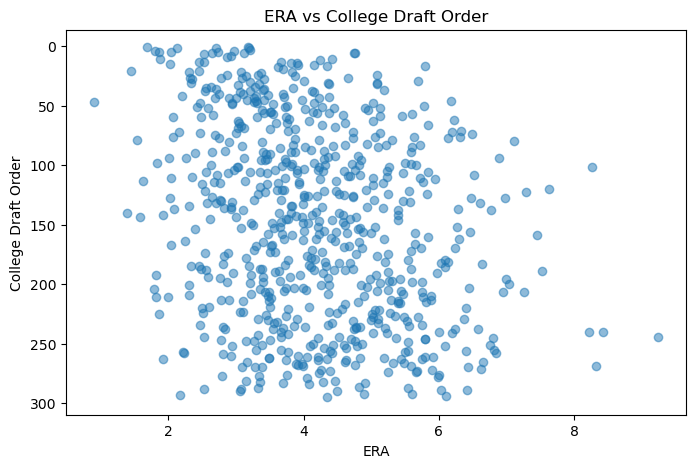

In [19]:
import matplotlib.pyplot as plt

plot_df = draftedClean_df[['era_pitch', 'College_Draft_Order']].dropna()

plt.figure(figsize=(8, 5))
plt.scatter(plot_df['era_pitch'], plot_df['College_Draft_Order'], alpha=0.5)
plt.xlabel('ERA')
plt.ylabel('College Draft Order')
plt.gca().invert_yaxis()  # pick 1 at top
plt.title('ERA vs College Draft Order')
plt.show()

In [20]:
# Build results dataframe
results_rank_df = pd.DataFrame({
    'name': test_df['nameascii'].values,
    'Predicted_College_Order': pred_order,
    'Actual_College_Order': actual_order,
})

results_rank_df = results_rank_df.sort_values('Actual_College_Order').reset_index(drop=True)

print(f"Player College Draft Order Predictions (Test Year: {test_year})")
print(f"Total college draftees: {len(results_rank_df)}\n")
display(results_rank_df.head(20))

Player College Draft Order Predictions (Test Year: 2025)
Total college draftees: 276



,name,Predicted_College_Order,Actual_College_Order
0,Kade Anderson,2,1
1,Liam Doyle,5,2
2,Aiva Arquette,9,3
3,Jamie Arnold,4,4
4,Gavin Kilen,12,5
5,Kyson Witherspoon,6,6
6,Marek Houston,22,7
7,Ike Irish,7,8
8,Andrew Fischer,1,9
9,Jace LaViolette,35,10


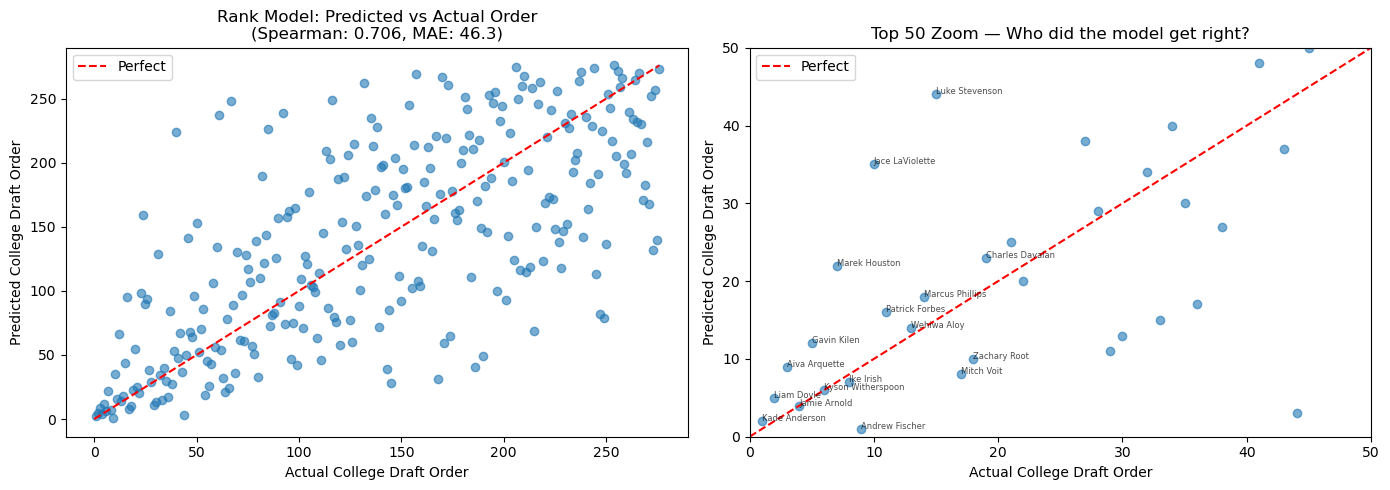

In [21]:
# Scatter plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

n_test = len(actual_order)

axes[0].scatter(actual_order, pred_order, alpha=0.6)
axes[0].plot([0, n_test], [0, n_test], 'r--', label='Perfect')
axes[0].set_xlabel('Actual College Draft Order')
axes[0].set_ylabel('Predicted College Draft Order')
axes[0].set_title(f'Rank Model: Predicted vs Actual Order\n(Spearman: {corr_order:.3f}, MAE: {mae_order:.1f})')
axes[0].legend()

axes[1].scatter(actual_order, pred_order, alpha=0.6)
# Add player labels for top 20
for _, row in results_rank_df.head(20).iterrows():
    if row['Actual_College_Order'] <= 20 or row['Predicted_College_Order'] <= 20:
        axes[1].annotate(row['name'], (row['Actual_College_Order'], row['Predicted_College_Order']),
                         fontsize=6, alpha=0.7)
axes[1].plot([0, 50], [0, 50], 'r--', label='Perfect')
axes[1].set_xlim(0, 50)
axes[1].set_ylim(0, 50)
axes[1].set_xlabel('Actual College Draft Order')
axes[1].set_ylabel('Predicted College Draft Order')
axes[1].set_title('Top 50 Zoom — Who did the model get right?')
axes[1].legend()

plt.tight_layout()
plt.show()

In [22]:
prospects = pd.read_csv('mlb_2025_draft_prospects_top250.csv')

# Compare with MLB Pipeline on matched players
results_rank_df['name_clean'] = results_rank_df['name'].str.strip().str.lower()
prospects['name_clean'] = prospects['name'].str.strip().str.lower()

comp = results_rank_df.merge(prospects[['name_clean', 'rank']], on='name_clean', how='inner')

# Re-rank everything among only matched players
comp = comp.sort_values('Actual_College_Order').reset_index(drop=True)
comp['Actual_Order_Matched'] = range(1, len(comp) + 1)

comp = comp.sort_values('Predicted_College_Order').reset_index(drop=True)
comp['Pred_Order_Matched'] = range(1, len(comp) + 1)

comp = comp.sort_values('rank').reset_index(drop=True)
comp['Pipeline_Order_Matched'] = range(1, len(comp) + 1)

corr_you, p_you = spearmanr(comp['Actual_Order_Matched'], comp['Pred_Order_Matched'])
corr_pipe, p_pipe = spearmanr(comp['Actual_Order_Matched'], comp['Pipeline_Order_Matched'])
mae_you = mean_absolute_error(comp['Actual_Order_Matched'], comp['Pred_Order_Matched'])
mae_pipe = mean_absolute_error(comp['Actual_Order_Matched'], comp['Pipeline_Order_Matched'])

print(f"Head-to-Head on Matched College Players (n={len(comp)})")
print(f"{'Comparison':<45} {'Spearman':>10}    {'P-Value':>8}  {'MAE':>10}")
print("-" * 80)
print(f"{'Your Rank Model vs Actual':<45} {corr_you:>10.3f}    {p_you:.2e} {mae_you:>10.1f}")
print(f"{'MLB Pipeline vs Actual':<45} {corr_pipe:>10.3f}    {p_pipe:.2e} {mae_pipe:>10.1f}")

comp = comp[['name', 'Pipeline_Order_Matched', 'Predicted_College_Order', 'Actual_College_Order']].copy()
comp.columns = ['name', 'MLB_Pipeline_College_Order', 'Predicted_College_Order', 'Actual_College_Order']
display(comp.sort_values('Actual_College_Order').reset_index(drop=True).head(25))

Head-to-Head on Matched College Players (n=99)
Comparison                                      Spearman     P-Value         MAE
--------------------------------------------------------------------------------
Your Rank Model vs Actual                          0.651    3.14e-13       17.7
MLB Pipeline vs Actual                             0.837    4.26e-27       11.6


,name,MLB_Pipeline_College_Order,Predicted_College_Order,Actual_College_Order
0,Kade Anderson,1,2,1
1,Liam Doyle,4,5,2
2,Aiva Arquette,3,9,3
3,Jamie Arnold,2,4,4
4,Gavin Kilen,11,12,5
5,Kyson Witherspoon,5,6,6
6,Marek Houston,7,22,7
7,Ike Irish,6,7,8
8,Andrew Fischer,12,1,9
9,Jace LaViolette,10,35,10


In [23]:
# Show top features with missing values
missing_summary = X.isnull().mean().sort_values(ascending=False)
print(missing_summary[missing_summary > 0].head(15))

TP_team        0.980332
k%_pitch       0.670612
hbp_pitch      0.670612
lob%_pitch     0.670612
babip_pitch    0.670612
whip_pitch     0.670612
avg_pitch      0.670612
k-bb%_pitch    0.670612
bb%_pitch      0.670612
hr/9_pitch     0.670612
k/bb_pitch     0.670612
bb/9_pitch     0.670612
k/9_pitch      0.670612
so_pitch       0.670612
bk_pitch       0.670612
dtype: float64


---
## Player Lookup by Name

Fuzzy-match a player and show stats, draft probability, predicted college order, and predicted signing bonus.

In [24]:
from difflib import get_close_matches

train_medians = df[df[year_col] < test_year].median(numeric_only=True)

def lookup_player(name_query, year=None):
    candidates = df if year is None else df[df[year_col] == year]
    names = candidates['nameascii'].dropna().unique().tolist()
    matches = get_close_matches(name_query, names, n=5, cutoff=0.4)
    if not matches:
        print(f"No match found for '{name_query}'"); return None

    player = candidates[candidates['nameascii'] == matches[0]].sort_values(year_col, ascending=False).iloc[0]
    role_name = {0: 'Pitcher', 1: 'Batter', 2: 'Both'}.get(player['role'], '?')

    print(f"{'='*60}")
    print(f"Player: {player['nameascii']}  |  Year: {int(player[year_col])}  |  Role: {role_name}")
    print(f"{'='*60}")

    if not pd.isna(player.get('api_height')):
        ft, inch = int(player['api_height'] // 12), int(player['api_height'] % 12)
        print(f"Height: {ft}'{inch}\"  |  Weight: {int(player.get('api_weight', 0))} lbs")
    pos_rev = {1:'C', 2:'SS', 3:'2B', 4:'3B', 5:'CF', 6:'LF', 7:'RF', 8:'IF', 9:'1B', 10:'OF', 11:'DH', 12:'P', 13:'TWP'}
    if not pd.isna(player.get('api_primaryPos')):
        print(f"Position: {pos_rev.get(int(player['api_primaryPos']), '?')}")

    print(f"\n--- Key Stats ---")
    if player['role'] in [0, 2]:
        for s in ['era_pitch', 'fip_pitch', 'k/9_pitch', 'bb/9_pitch', 'whip_pitch', 'ip_pitch', 'so_pitch']:
            if not pd.isna(player.get(s)): print(f"  {s}: {player[s]:.2f}")
    if player['role'] in [1, 2]:
        for s in ['avg_bat', 'ops_bat', 'hr_bat', 'wrc+_bat', 'woba_bat', 'slg_bat', 'bb%_bat', 'k%_bat']:
            if not pd.isna(player.get(s)):
                v = player[s]; print(f"  {s}: {v:.3f}" if isinstance(v, float) and v < 10 else f"  {s}: {v:.1f}")

    cls_df = pd.DataFrame([player.reindex(features).values], columns=features)
    draft_prob = draft_model.predict_proba(cls_df)[0][1]
    rank_df = pd.DataFrame([player.reindex(pick_features).values], columns=pick_features)
    rank_pred = model_rank.predict(rank_df)[0]

    print(f"\n--- Predictions ---")
    print(f"Draft Probability: {draft_prob*100:.1f}%")
    print(f"Predicted College Draft Order: ~{int(round(rank_pred))}")

    if not pd.isna(player.get('Pick')):
        print(f"\n--- Actual ---")
        print(f"Pick: {int(player['Pick'])} (Round {int(player.get('Round', 0))})")
        if not pd.isna(player.get('College_Draft_Order')): print(f"College Order: {int(player['College_Draft_Order'])}")
        if not pd.isna(player.get('api_signingBonus')): print(f"Signing Bonus: ${player['api_signingBonus']*1e6:,.0f}")
    if len(matches) > 1: print(f"\nOther matches: {matches[1:]}")
    return player

print("lookup_player() defined. Usage: lookup_player('Jace LaViolette')")

lookup_player() defined. Usage: lookup_player('Jace LaViolette')


In [25]:
lookup_player('Jace LaViolette')

Player: Jace LaViolette  |  Year: 2025  |  Role: Batter

--- Key Stats ---
  avg_bat: 0.258
  ops_bat: 1.003
  hr_bat: 18.0
  wrc+_bat: 119.7
  woba_bat: 0.435
  slg_bat: 0.576
  bb%_bat: 0.218
  k%_bat: 0.252

--- Predictions ---
Draft Probability: 99.8%
Predicted College Draft Order: ~74

--- Actual ---
Pick: 27 (Round 1)

Other matches: ['Jack Colette', 'Jack Little', 'Jared Viertel', 'Wil LaFollette']


age                                 21.0
nameascii                Jace LaViolette
year                                2025
w_pitch                              NaN
l_pitch                              NaN
era_pitch                            NaN
g_pitch                              NaN
gs_pitch                             NaN
cg_pitch                             NaN
sho_pitch                            NaN
sv_pitch                             NaN
ip_pitch                             NaN
tbf_pitch                            NaN
h_pitch                              NaN
r_pitch                              NaN
er_pitch                             NaN
hr_pitch                             NaN
bb_pitch                             NaN
hbp_pitch                            NaN
wp_pitch                             NaN
bk_pitch                             NaN
so_pitch                             NaN
k/9_pitch                            NaN
bb/9_pitch                           NaN
k/bb_pitch      

In [26]:
lookup_player('Kade Anderson')

Player: Kade Anderson  |  Year: 2025  |  Role: Pitcher

--- Key Stats ---
  era_pitch: 3.18
  fip_pitch: 3.42
  k/9_pitch: 13.61
  bb/9_pitch: 2.65
  whip_pitch: 1.06
  ip_pitch: 119.00
  so_pitch: 180.00

--- Predictions ---
Draft Probability: 98.5%
Predicted College Draft Order: ~11

--- Actual ---
Pick: 3 (Round 1)

Other matches: ['Nate Anderson', 'Kaden Amundson', 'Drake Anderson', 'Chase Anderson']


age                               20.0
nameascii                Kade Anderson
year                              2025
w_pitch                           12.0
l_pitch                            1.0
era_pitch                     3.176471
g_pitch                           19.0
gs_pitch                          19.0
cg_pitch                           2.0
sho_pitch                          2.0
sv_pitch                           0.0
ip_pitch                         119.0
tbf_pitch                        481.0
h_pitch                           91.0
r_pitch                           44.0
er_pitch                          42.0
hr_pitch                          16.0
bb_pitch                          35.0
hbp_pitch                          5.0
wp_pitch                           5.0
bk_pitch                           0.0
so_pitch                         180.0
k/9_pitch                    13.613445
bb/9_pitch                    2.647059
k/bb_pitch                    5.142857
hr/9_pitch               

In [30]:
lookup_player('alex mccoy')

Player: Alex McCoy  |  Year: 2024  |  Role: Batter

--- Key Stats ---
  avg_bat: 0.306
  ops_bat: 0.893
  hr_bat: 11.0
  wrc+_bat: 106.5
  woba_bat: 0.400
  slg_bat: 0.509
  bb%_bat: 0.078
  k%_bat: 0.192

--- Predictions ---
Draft Probability: 31.7%
Predicted College Draft Order: ~245

Other matches: ['Callen Nuccio', 'Kyle McCoy', 'Jake McCoy', 'Caleb Floyd']


age                            22.0
nameascii                Alex McCoy
year                           2024
w_pitch                         NaN
l_pitch                         NaN
era_pitch                       NaN
g_pitch                         NaN
gs_pitch                        NaN
cg_pitch                        NaN
sho_pitch                       NaN
sv_pitch                        NaN
ip_pitch                        NaN
tbf_pitch                       NaN
h_pitch                         NaN
r_pitch                         NaN
er_pitch                        NaN
hr_pitch                        NaN
bb_pitch                        NaN
hbp_pitch                       NaN
wp_pitch                        NaN
bk_pitch                        NaN
so_pitch                        NaN
k/9_pitch                       NaN
bb/9_pitch                      NaN
k/bb_pitch                      NaN
hr/9_pitch                      NaN
k%_pitch                        NaN
bb%_pitch                   

In [31]:
lookup_player('cooper clark')

Player: Cooper Clark  |  Year: 2024  |  Role: Pitcher

--- Key Stats ---
  era_pitch: 7.71
  fip_pitch: 5.55
  k/9_pitch: 8.24
  bb/9_pitch: 2.63
  whip_pitch: 1.58
  ip_pitch: 51.10
  so_pitch: 47.00

--- Predictions ---
Draft Probability: 0.1%
Predicted College Draft Order: ~231

Other matches: ['Cooper Blauser', 'Cooper Mrowka', 'Cooper Thacker', 'Cooper Katskee']


age                               NaN
nameascii                Cooper Clark
year                             2024
w_pitch                           4.0
l_pitch                           1.0
era_pitch                    7.714286
g_pitch                          13.0
gs_pitch                         11.0
cg_pitch                          0.0
sho_pitch                         0.0
sv_pitch                          0.0
ip_pitch                         51.1
tbf_pitch                       242.0
h_pitch                          66.0
r_pitch                          47.0
er_pitch                         44.0
hr_pitch                          7.0
bb_pitch                         15.0
hbp_pitch                        11.0
wp_pitch                          8.0
bk_pitch                          0.0
so_pitch                         47.0
k/9_pitch                     8.24026
bb/9_pitch                    2.62987
k/bb_pitch                   3.133333
hr/9_pitch                   1.227273
k%_pitch    

---
## Custom Stats Input

Predict draft probability, college order, and signing bonus from custom stat values.

In [27]:
PITCHER_TEMPLATE = {
    'age': 21, 'era_pitch': 3.50, 'fip_pitch': 3.40, 'ip_pitch': 90.0,
    'so_pitch': 100, 'bb_pitch': 25, 'h_pitch': 75, 'hr_pitch': 5,
    'g_pitch': 15, 'gs_pitch': 14, 'w_pitch': 8, 'l_pitch': 3,
    'k/9_pitch': 10.0, 'bb/9_pitch': 2.5, 'k/bb_pitch': 4.0, 'whip_pitch': 1.10,
    'k%_pitch': 0.28, 'bb%_pitch': 0.07, 'k-bb%_pitch': 0.21,
    'avg_pitch': 0.230, 'babip_pitch': 0.290, 'lob%_pitch': 0.72,
    'hr/9_pitch': 0.5, 'e-f_pitch': 0.5, 'sv_pitch': 0, 'tbf_pitch': 350,
    'r_pitch': 40, 'er_pitch': 35, 'hbp_pitch': 5, 'wp_pitch': 3, 'bk_pitch': 0, 'cg_pitch': 0, 'sho_pitch': 0,
}
BATTER_TEMPLATE = {
    'age': 21, 'avg_bat': 0.300, 'ops_bat': 0.900, 'hr_bat': 15,
    'wrc+_bat': 130, 'woba_bat': 0.400, 'slg_bat': 0.520, 'obp_bat': 0.400,
    'bb%_bat': 0.12, 'k%_bat': 0.15, 'iso_bat': 0.200,
    'g_bat': 55, 'ab_bat': 200, 'pa_bat': 240, 'h_bat': 60,
    '1b_bat': 35, '2b_bat': 15, '3b_bat': 2, 'r_bat': 40,
    'rbi_bat': 45, 'bb_bat': 30, 'so_bat': 35, 'hbp_bat': 5,
    'sf_bat': 3, 'sh_bat': 1, 'gdp_bat': 3, 'sb_bat': 10, 'cs_bat': 2,
    'spd_bat': 5.0, 'babip_bat': 0.330, 'wsb_bat': 1.0, 'wrc_bat': 40.0, 'wraa_bat': 15.0, 'bb/k_bat': 0.8,
}

def predict_from_stats(role, age, stats_dict, team_stats_dict=None):
    role_num = {'Pitcher': 0, 'Batter': 1, 'Both': 2}[role]
    row = pd.Series(index=pick_features, dtype=float)
    row[:] = np.nan
    row['age'] = age; row['role'] = role_num
    for k, v in stats_dict.items():
        if k in row.index: row[k] = v
    if team_stats_dict:
        for k, v in team_stats_dict.items():
            if k in row.index: row[k] = v
    else:
        for f in row.index:
            if pd.isna(row[f]) and f.endswith('_team') and f in train_medians.index:
                row[f] = train_medians[f]

    cls_df = pd.DataFrame([row.reindex(features).values], columns=features)
    draft_prob = draft_model.predict_proba(cls_df)[0][1]
    rank_df = pd.DataFrame([row.reindex(pick_features).values], columns=pick_features)
    rank_pred = model_rank.predict(rank_df)[0]

    print(f"{'='*50}")
    print(f"Custom {role} Prediction (age {age})")
    print(f"{'='*50}")
    print(f"Draft Probability: {draft_prob*100:.1f}%")
    print(f"Predicted College Draft Order: ~{int(round(rank_pred))}")

print("predict_from_stats() defined. Templates: PITCHER_TEMPLATE, BATTER_TEMPLATE")

predict_from_stats() defined. Templates: PITCHER_TEMPLATE, BATTER_TEMPLATE


In [28]:
predict_from_stats('Pitcher', 21, {
    'era_pitch': 2.50, 'fip_pitch': 2.80, 'so_pitch': 120, 'ip_pitch': 95.0,
    'bb_pitch': 20, 'k/9_pitch': 11.4, 'bb/9_pitch': 1.9, 'whip_pitch': 0.95,
    'k%_pitch': 0.32, 'bb%_pitch': 0.06, 'k-bb%_pitch': 0.26,
    'g_pitch': 16, 'gs_pitch': 16, 'w_pitch': 10, 'l_pitch': 2,
})

Custom Pitcher Prediction (age 21)
Draft Probability: 99.8%
Predicted College Draft Order: ~104


In [29]:
predict_from_stats('Batter', 21, {
    'avg_bat': 0.330, 'ops_bat': 1.050, 'hr_bat': 22, 'wrc+_bat': 170,
    'woba_bat': 0.440, 'slg_bat': 0.620, 'obp_bat': 0.430,
    'bb%_bat': 0.14, 'k%_bat': 0.12, 'iso_bat': 0.280,
    'g_bat': 58, 'ab_bat': 210, 'pa_bat': 255, 'h_bat': 69,
    'r_bat': 55, 'rbi_bat': 60, 'sb_bat': 15,
})

Custom Batter Prediction (age 21)
Draft Probability: 98.6%
Predicted College Draft Order: ~150


In [33]:
# Cooper Clark
predict_from_stats('Pitcher', 19, {
    'era_pitch': 7.714286, 'fip_pitch': 5.554999, 'so_pitch': 47, 'ip_pitch': 51.1,
    'bb_pitch': 15, 'k/9_pitch': 8.24, 'bb/9_pitch': 2.63, 'whip_pitch': 1.58,
    'k%_pitch': 0.194, 'bb%_pitch': 0.062, 'k-bb%_pitch': 0.132,
    'g_pitch': 13, 'gs_pitch': 11, 'w_pitch': 4, 'l_pitch': 1,
})

Custom Pitcher Prediction (age 19)
Draft Probability: 0.1%
Predicted College Draft Order: ~212
